# Embedding Quality Analysis

Compare `model_no_orthogonal` vs `model_orthogonal` across three quality dimensions:
- **Separation quality**: same-team vs different-team cosine overlap + clustering metrics
- **Retrieval quality**: team-consistent nearest-neighbor precision/recall curves
- **Geometry quality**: norm spread, eigenspectrum concentration, and angular spread

The notebook ends with a refined cosine-distribution comparison for driver-constructor pairs.

In [44]:
import sys, os, warnings
sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../"))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from scipy.stats import ks_2samp

from models.pipeline_fusion import F1OrthogonalPipeline
from train import build_graph, get_active_task, _build_instances_from_task
import config as cfg

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%matplotlib inline

In [45]:
# ---------------------------------------------------------------------------
# Config — adjust these if your setup differs
# ---------------------------------------------------------------------------
LATENT_DIM = 32             # must match training latent_dim
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TOP_N_TEAMS = 6             # top teams shown in overlap diagnostics
K_VALUES = [1, 5, 10]       # neighborhood quality cutoffs
YEAR_BUCKET = 3             # years per bucket for temporal consistency proxy
ANGULAR_PAIR_SAMPLES = 50000  # sampled driver-driver pairs for angular histogram
PCA_COMPONENTS = 16         # eigenspectrum diagnostics cap

MODEL_NAMES = ["model_no_orthogonal", "model_orthogonal"]
MODEL_LABELS = ["No Orthogonal", "Orthogonal"]

for name in MODEL_NAMES:
    path = f"../output/models/{name}.pth"
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model not found: {path}. Train it first on the GPU machine.")

In [46]:
# ---------------------------------------------------------------------------
# 1. Load DB and build metadata (driver -> team, driver -> year)
# ---------------------------------------------------------------------------
print("Loading DB & metadata...")

task, outcome_lookup = get_active_task()
db = task.dataset.get_db(upto_test_timestamp=False)

instances = _build_instances_from_task(task, outcome_lookup)

# Per-driver: most frequent constructor -> team name
driver_team_id = instances.groupby("driverId")["constructorId"] \
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
driver_year_mean = instances.groupby("driverId")["year"].mean()

# Human-readable names
constructors_df = db.table_dict["constructors"].df.reset_index(drop=True)
drivers_df = db.table_dict["drivers"].df.reset_index(drop=True)

cons_id_to_name = constructors_df.set_index("constructorId")["name"].to_dict()
driver_id_to_name = drivers_df.set_index("driverId").apply(
    lambda r: f"{r['forename']} {r['surname']}", axis=1
).to_dict()

n_drivers = len(drivers_df)
n_constructors = len(constructors_df)
active_driver_ids = sorted(instances["driverId"].unique().tolist())
print(f"Drivers: {n_drivers}, Constructors: {n_constructors}, Instances: {len(instances)}")
print(f"Active drivers with race records: {len(active_driver_ids)}")

Loading DB & metadata...
Drivers: 857, Constructors: 211, Instances: 9400
Active drivers with race records: 122


In [47]:
# ---------------------------------------------------------------------------
# 2. Build graph
# ---------------------------------------------------------------------------
print("Building graph...")

graph_data, node_to_col_names_dict, node_to_col_stats = build_graph(db)

num_nodes_dict = {nt: graph_data[nt].num_nodes for nt in graph_data.node_types}

# Keep CPU copy for tf_dict (TensorFrame doesn't move with .to())
graph_cpu = graph_data
graph_data = graph_data.to(DEVICE)

print("Node types:", graph_data.node_types)
print("Edge types:", len(graph_data.edge_types))

Building graph...


Node types: ['constructor_results', 'drivers', 'constructor_standings', 'standings', 'circuits', 'constructors', 'qualifying', 'races', 'results']
Edge types: 26


In [48]:
# ---------------------------------------------------------------------------
# 3. Load models and extract ALL driver + constructor embeddings
# ---------------------------------------------------------------------------
def load_model(name):
    model = F1OrthogonalPipeline(
        num_nodes_dict=num_nodes_dict,
        node_to_col_names_dict=node_to_col_names_dict,
        node_to_col_stats=node_to_col_stats,
        latent_dim=LATENT_DIM,
    ).to(DEVICE)

    # Materialize lazy parameters (encoder + graph convs) before shape checks.
    if model.encoder is not None:
        with torch.no_grad():
            x_init = model.encoder(graph_cpu.tf_dict)
            _ = model.graph_encoder(x_init, graph_data.edge_index_dict)

    path = f"../output/models/{name}.pth"
    ckpt = torch.load(path, map_location=DEVICE)

    # Handle schema drift between saved checkpoint and current RelBench preprocessing.
    model_state = model.state_dict()
    compatible_state = {}
    skipped_shape = []

    for k, v in ckpt.items():
        if k not in model_state:
            continue
        if model_state[k].shape != v.shape:
            skipped_shape.append((k, tuple(v.shape), tuple(model_state[k].shape)))
            continue
        compatible_state[k] = v

    missing, unexpected = model.load_state_dict(compatible_state, strict=False)

    if skipped_shape:
        print(f"  Skipped {len(skipped_shape)} incompatible tensor(s):")
        for k, old_shape, new_shape in skipped_shape[:8]:
            print(f"    - {k}: ckpt{old_shape} vs model{new_shape}")
        if len(skipped_shape) > 8:
            print(f"    ... and {len(skipped_shape) - 8} more")

    if missing:
        print(f"  Missing keys after compatibility load: {len(missing)}")
    if unexpected:
        print(f"  Unexpected keys after compatibility load: {len(unexpected)}")

    model.eval()
    return model

embeddings = {}  # label -> (drivers_np, constructors_np)

for name, label in zip(MODEL_NAMES, MODEL_LABELS):
    print(f"Loading {label}...")
    model = load_model(name)

    with torch.no_grad():
        # Encoder processes CPU tf_dict -> outputs tensors on model device
        x_dict = model.encoder(graph_cpu.tf_dict) if model.encoder is not None else graph_cpu.x_dict
        out_dict = model.graph_encoder(x_dict, graph_data.edge_index_dict)

    drv = out_dict["drivers"].cpu().numpy()
    cons = out_dict["constructors"].cpu().numpy()
    embeddings[label] = (drv, cons)
    print(f"  drivers: {drv.shape}, constructors: {cons.shape}")

Loading No Orthogonal...
  Skipped 12 incompatible tensor(s):
    - encoder.encoders.standings.encoder.encoder_dict.numerical.weight: ckpt(2, 128) vs model(3, 128)
    - encoder.encoders.standings.encoder.encoder_dict.numerical.bias: ckpt(2, 128) vs model(3, 128)
    - encoder.encoders.standings.encoder.encoder_dict.numerical.mean: ckpt(2,) vs model(3,)
    - encoder.encoders.standings.encoder.encoder_dict.numerical.std: ckpt(2,) vs model(3,)
    - encoder.encoders.qualifying.encoder.encoder_dict.numerical.weight: ckpt(1, 128) vs model(2, 128)
    - encoder.encoders.qualifying.encoder.encoder_dict.numerical.bias: ckpt(1, 128) vs model(2, 128)
    - encoder.encoders.qualifying.encoder.encoder_dict.numerical.mean: ckpt(1,) vs model(2,)
    - encoder.encoders.qualifying.encoder.encoder_dict.numerical.std: ckpt(1,) vs model(2,)
    ... and 4 more
  Missing keys after compatibility load: 12
  drivers: (857, 32), constructors: (211, 32)
Loading Orthogonal...
  Skipped 12 incompatible tensor(

In [49]:
# ---------------------------------------------------------------------------
# 4. Build aligned analysis frames (active drivers only)
# ---------------------------------------------------------------------------
print("Preparing aligned embeddings for diagnostics...")

active_driver_ids_arr = np.array(active_driver_ids, dtype=int)

driver_meta_rows = []
for driver_id in active_driver_ids_arr:
    constructor_id = driver_team_id.get(int(driver_id), -1)
    team_name = cons_id_to_name.get(constructor_id, "Unknown")
    year_val = driver_year_mean.get(int(driver_id), np.nan)

    if pd.isna(year_val):
        year_bucket = -1
    else:
        year_bucket = int(np.floor(float(year_val) / YEAR_BUCKET) * YEAR_BUCKET)

    driver_meta_rows.append({
        "driverId": int(driver_id),
        "driver": driver_id_to_name.get(int(driver_id), f"id_{int(driver_id)}"),
        "team": team_name,
        "year": float(year_val) if not pd.isna(year_val) else np.nan,
        "year_bucket": year_bucket,
    })

driver_meta = pd.DataFrame(driver_meta_rows)

# Focus metrics on teams with enough support for stable comparisons.
team_counts = driver_meta[driver_meta["team"] != "Unknown"]["team"].value_counts()
top_teams = team_counts.head(TOP_N_TEAMS).index.tolist()
driver_meta["team_group"] = driver_meta["team"].apply(lambda t: t if t in top_teams else "Other")

analysis = {}
for label in MODEL_LABELS:
    drv, cons = embeddings[label]
    drv_active = drv[active_driver_ids_arr]

    analysis[label] = {
        "drv": drv,
        "cons": cons,
        "drv_active": drv_active,
        "drv_norm": normalize(drv_active, norm="l2"),
        "cons_norm": normalize(cons, norm="l2"),
    }

print(f"Top teams considered: {top_teams}")
print(f"Active drivers used in diagnostics: {len(driver_meta)}")

Preparing aligned embeddings for diagnostics...
Top teams considered: ['Williams', 'Minardi', 'Toro Rosso', 'Ferrari', 'McLaren', 'Renault']
Active drivers used in diagnostics: 122


In [50]:
# ---------------------------------------------------------------------------
# 5. Compute metric tables (separation + retrieval + geometry)
# ---------------------------------------------------------------------------
rng = np.random.default_rng(42)
separation_rows, retrieval_rows, geometry_rows = [], [], []

valid_for_team_metrics = (driver_meta["team_group"] != "Other") & (driver_meta["team"] != "Unknown")
y_team = driver_meta.loc[valid_for_team_metrics, "team_group"].to_numpy()
y_year = driver_meta.loc[valid_for_team_metrics, "year_bucket"].to_numpy()

for label in MODEL_LABELS:
    drv_norm = analysis[label]["drv_norm"]
    cons_norm = analysis[label]["cons_norm"]

    # --- Separation diagnostics ---
    team_cos = drv_norm @ drv_norm.T
    iu = np.triu_indices_from(team_cos, k=1)
    same_team_mask = (
        driver_meta["team_group"].to_numpy()[:, None] == driver_meta["team_group"].to_numpy()[None, :]
    )
    valid_team_mask = (driver_meta["team_group"].to_numpy() != "Other") & (driver_meta["team"].to_numpy() != "Unknown")
    valid_pair_mask = valid_team_mask[:, None] & valid_team_mask[None, :]

    team_cos_upper = team_cos[iu]
    same_upper_mask = (same_team_mask & valid_pair_mask)[iu]
    diff_upper_mask = ((~same_team_mask) & valid_pair_mask)[iu]

    same_vals = team_cos_upper[same_upper_mask]
    diff_vals = team_cos_upper[diff_upper_mask]

    if len(np.unique(y_team)) > 1 and len(y_team) > len(np.unique(y_team)):
        sep_silhouette = silhouette_score(drv_norm[valid_for_team_metrics], y_team, metric="cosine")
        sep_db = davies_bouldin_score(drv_norm[valid_for_team_metrics], y_team)
    else:
        sep_silhouette = np.nan
        sep_db = np.nan

    separation_rows.append({
        "model": label,
        "silhouette_cosine": float(sep_silhouette),
        "davies_bouldin": float(sep_db),
        "same_team_mean_cos": float(np.mean(same_vals)) if len(same_vals) else np.nan,
        "diff_team_mean_cos": float(np.mean(diff_vals)) if len(diff_vals) else np.nan,
        "cosine_gap": float(np.mean(same_vals) - np.mean(diff_vals)) if len(same_vals) and len(diff_vals) else np.nan,
    })
    analysis[label]["same_team_cos"] = same_vals
    analysis[label]["diff_team_cos"] = diff_vals

    # --- Retrieval diagnostics ---
    nbrs = NearestNeighbors(n_neighbors=max(K_VALUES) + 1, metric="cosine").fit(drv_norm)
    nn_idx = nbrs.kneighbors(return_distance=False)[:, 1:]  # remove self

    team_labels = driver_meta["team_group"].to_numpy()
    year_labels = driver_meta["year_bucket"].to_numpy()
    valid_anchor = valid_for_team_metrics.to_numpy()

    for k in K_VALUES:
        neigh = nn_idx[:, :k]
        team_match = (team_labels[neigh] == team_labels[:, None])
        year_match = (year_labels[neigh] == year_labels[:, None])

        precision_k = np.mean(team_match[valid_anchor])
        recall_k = np.mean(np.any(team_match[valid_anchor], axis=1))
        top1_team = np.mean(team_match[valid_anchor, 0])
        top1_team_year = np.mean((team_match & year_match)[valid_anchor, 0])

        retrieval_rows.append({
            "model": label,
            "k": int(k),
            "precision_at_k": float(precision_k),
            "recall_at_k": float(recall_k),
            "top1_team_hit": float(top1_team),
            "top1_team_year_hit": float(top1_team_year),
        })

    # --- Geometry diagnostics ---
    drv_norms = np.linalg.norm(analysis[label]["drv_active"], axis=1)
    cons_norms = np.linalg.norm(analysis[label]["cons"], axis=1)

    pca_components = min(PCA_COMPONENTS, drv_norm.shape[1], drv_norm.shape[0])
    pca = PCA(n_components=pca_components, random_state=42)
    pca.fit(drv_norm)
    cumvar = np.cumsum(pca.explained_variance_ratio_)

    n = len(drv_norm)
    if n > 1:
        idx_i = rng.integers(0, n, size=ANGULAR_PAIR_SAMPLES)
        idx_j = rng.integers(0, n, size=ANGULAR_PAIR_SAMPLES)
        valid = idx_i != idx_j
        pair_cos = np.sum(drv_norm[idx_i[valid]] * drv_norm[idx_j[valid]], axis=1)
    else:
        pair_cos = np.array([])

    geometry_rows.append({
        "model": label,
        "driver_norm_mean": float(np.mean(drv_norms)),
        "driver_norm_std": float(np.std(drv_norms)),
        "constructor_norm_mean": float(np.mean(cons_norms)),
        "constructor_norm_std": float(np.std(cons_norms)),
        "pc80_components": int(np.searchsorted(cumvar, 0.80) + 1),
        "pc95_components": int(np.searchsorted(cumvar, 0.95) + 1),
        "angular_cos_mean": float(np.mean(pair_cos)) if len(pair_cos) else np.nan,
        "angular_cos_std": float(np.std(pair_cos)) if len(pair_cos) else np.nan,
    })

    analysis[label]["driver_norms"] = drv_norms
    analysis[label]["constructor_norms"] = cons_norms
    analysis[label]["cumvar"] = cumvar
    analysis[label]["angular_pair_cos"] = pair_cos

separation_df = pd.DataFrame(separation_rows)
retrieval_df = pd.DataFrame(retrieval_rows)
geometry_df = pd.DataFrame(geometry_rows)

print("Separation metrics")
display(separation_df.round(4))
print("Retrieval metrics")
display(retrieval_df.round(4))
print("Geometry metrics")
display(geometry_df.round(4))

Separation metrics


,model,silhouette_cosine,davies_bouldin,same_team_mean_cos,diff_team_mean_cos,cosine_gap
0,No Orthogonal,-0.2896,4.7431,0.8346,0.7529,0.0816
1,Orthogonal,-0.3368,5.2133,0.9852,0.9862,-0.0010


Retrieval metrics


,model,k,precision_at_k,recall_at_k,top1_team_hit,top1_team_year_hit
0,No Orthogonal,1,0.2653,0.2653,0.2653,0.1020
1,No Orthogonal,5,0.1633,0.5510,0.2653,0.1020
2,No Orthogonal,10,0.1265,0.6327,0.2653,0.1020
3,Orthogonal,1,0.1633,0.1633,0.1633,0.0612
4,Orthogonal,5,0.1429,0.5918,0.1633,0.0612
5,Orthogonal,10,0.1163,0.6531,0.1633,0.0612


Geometry metrics


,model,driver_norm_mean,driver_norm_std,constructor_norm_mean,constructor_norm_std,pc80_components,pc95_components,angular_cos_mean,angular_cos_std
0,No Orthogonal,6.2516,0.1368,6.0122,0.1060,2,3,0.7769,0.2226
1,Orthogonal,5.6107,0.0008,5.6154,0.0046,2,4,0.9897,0.0347


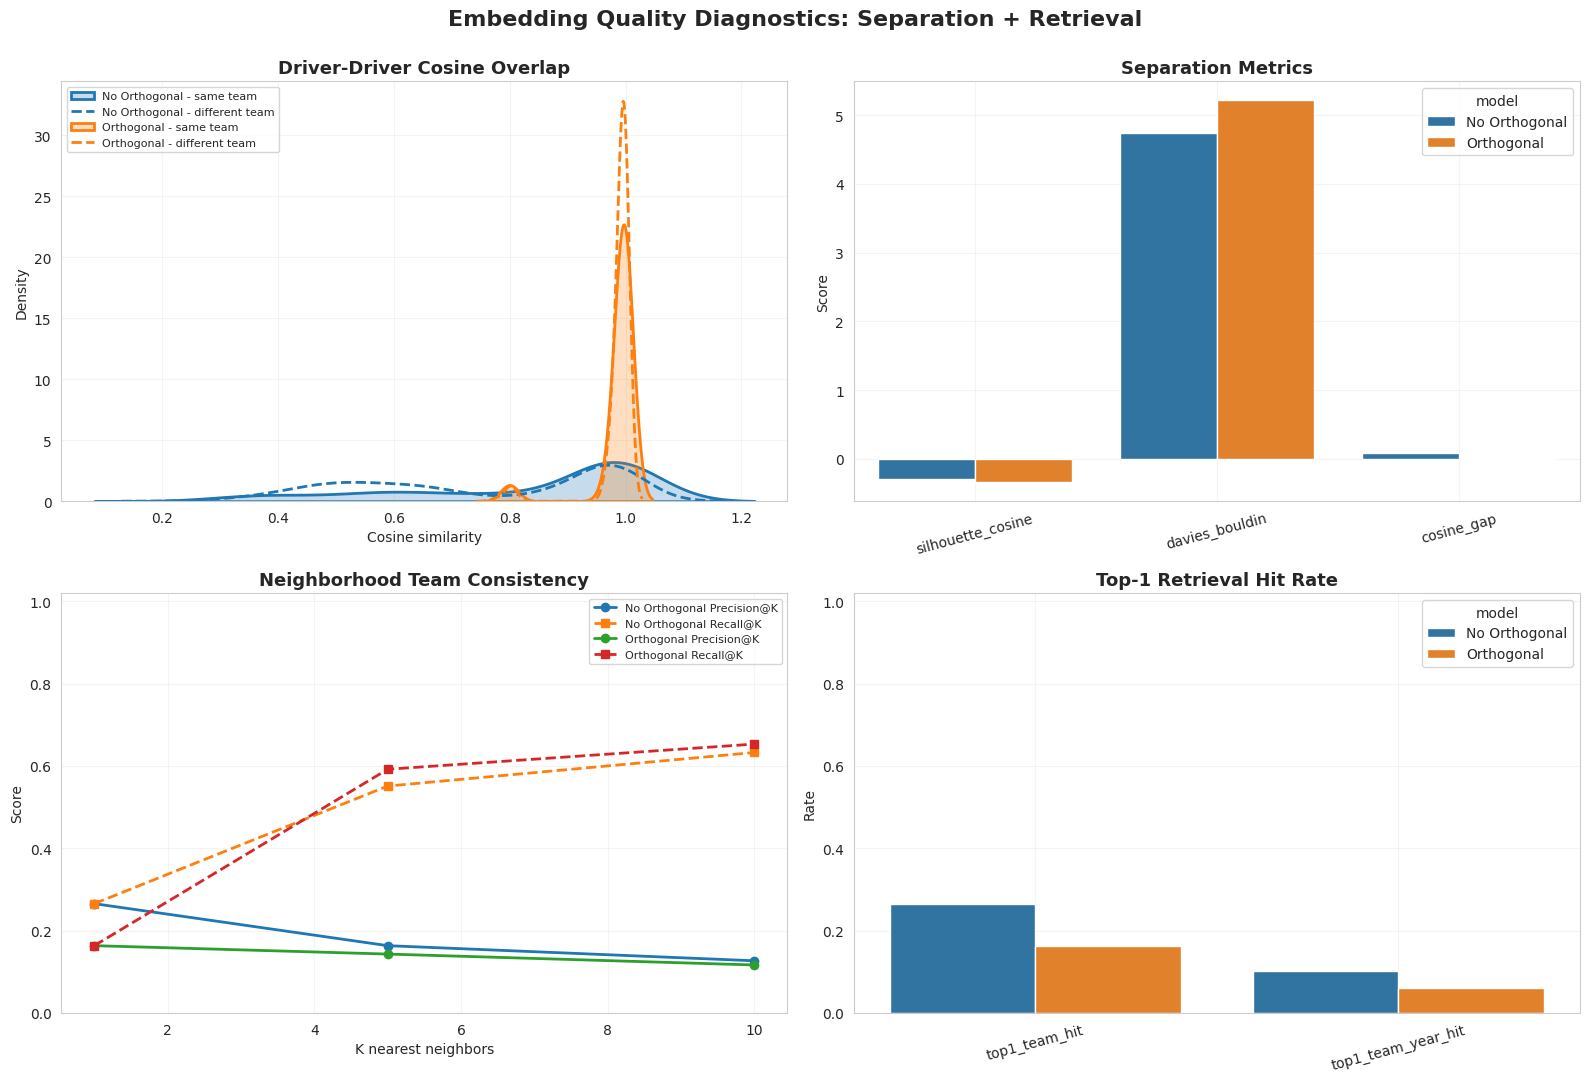

In [51]:
# ---------------------------------------------------------------------------
# 6. Separation + retrieval diagnostics
# ---------------------------------------------------------------------------
os.makedirs("./output", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 6a. Same-team vs different-team cosine overlap
for label in MODEL_LABELS:
    same_vals = analysis[label]["same_team_cos"]
    diff_vals = analysis[label]["diff_team_cos"]

    if len(same_vals) > 1:
        sns.kdeplot(
            same_vals,
            ax=axes[0, 0],
            fill=True,
            alpha=0.25,
            linewidth=2,
            label=f"{label} - same team",
        )
    if len(diff_vals) > 1:
        sns.kdeplot(
            diff_vals,
            ax=axes[0, 0],
            fill=False,
            linestyle="--",
            linewidth=2,
            label=f"{label} - different team",
        )

axes[0, 0].set_title("Driver-Driver Cosine Overlap", fontsize=13, weight="bold")
axes[0, 0].set_xlabel("Cosine similarity")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend(fontsize=8, frameon=True)
axes[0, 0].grid(alpha=0.2)

# 6b. Metric summary bars
sep_melt = separation_df.melt(
    id_vars="model",
    value_vars=["silhouette_cosine", "davies_bouldin", "cosine_gap"],
    var_name="metric",
    value_name="value",
)
sns.barplot(data=sep_melt, x="metric", y="value", hue="model", ax=axes[0, 1])
axes[0, 1].set_title("Separation Metrics", fontsize=13, weight="bold")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Score")
axes[0, 1].tick_params(axis="x", rotation=15)
axes[0, 1].grid(alpha=0.2)

# 6c. Precision@K and Recall@K
for label in MODEL_LABELS:
    sub = retrieval_df[retrieval_df["model"] == label].sort_values("k")
    axes[1, 0].plot(sub["k"], sub["precision_at_k"], marker="o", linewidth=2, label=f"{label} Precision@K")
    axes[1, 0].plot(sub["k"], sub["recall_at_k"], marker="s", linestyle="--", linewidth=2, label=f"{label} Recall@K")

axes[1, 0].set_title("Neighborhood Team Consistency", fontsize=13, weight="bold")
axes[1, 0].set_xlabel("K nearest neighbors")
axes[1, 0].set_ylabel("Score")
axes[1, 0].set_ylim(0, 1.02)
axes[1, 0].grid(alpha=0.2)
axes[1, 0].legend(fontsize=8, frameon=True)

# 6d. Top-1 hit rates
hit_df = retrieval_df[retrieval_df["k"] == min(K_VALUES)][["model", "top1_team_hit", "top1_team_year_hit"]]
hit_melt = hit_df.melt(
    id_vars="model",
    value_vars=["top1_team_hit", "top1_team_year_hit"],
    var_name="metric",
    value_name="value",
)
sns.barplot(data=hit_melt, x="metric", y="value", hue="model", ax=axes[1, 1])
axes[1, 1].set_title("Top-1 Retrieval Hit Rate", fontsize=13, weight="bold")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Rate")
axes[1, 1].set_ylim(0, 1.02)
axes[1, 1].tick_params(axis="x", rotation=15)
axes[1, 1].grid(alpha=0.2)

fig.suptitle("Embedding Quality Diagnostics: Separation + Retrieval", fontsize=16, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("./output/embedding_quality_separation_retrieval.png", dpi=220, bbox_inches="tight")
plt.show()

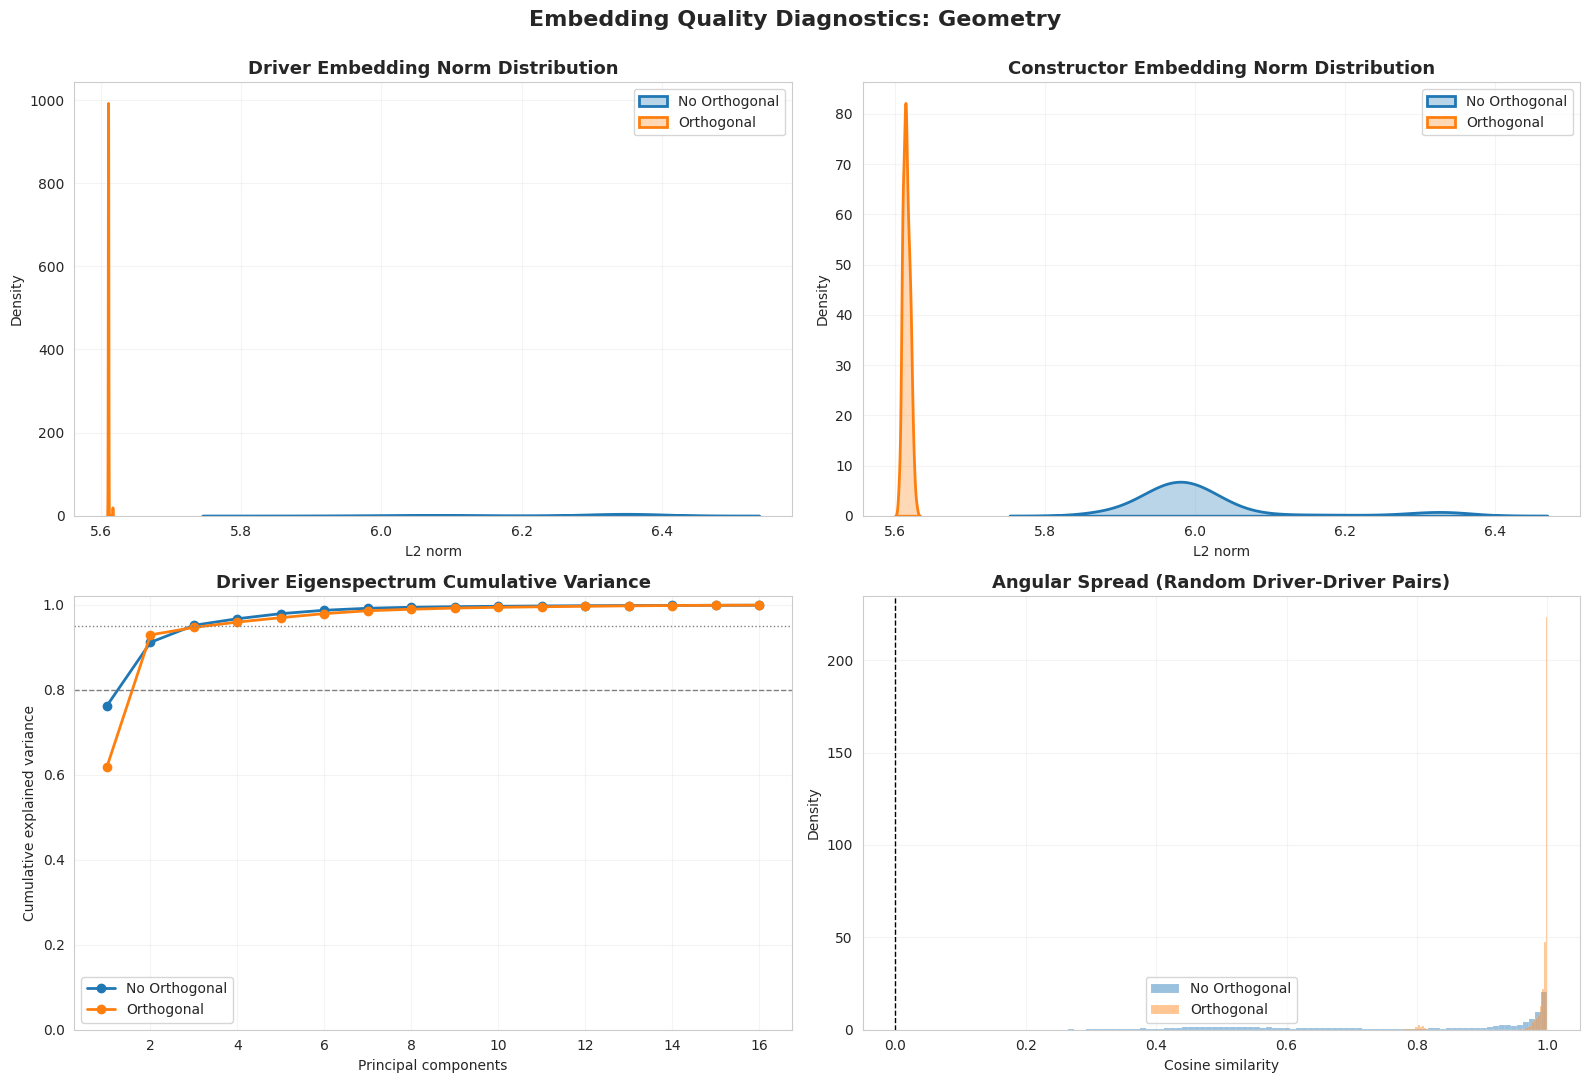

In [52]:
# ---------------------------------------------------------------------------
# 7. Geometry diagnostics
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 7a. Driver norm distribution
for label in MODEL_LABELS:
    sns.kdeplot(
        analysis[label]["driver_norms"],
        ax=axes[0, 0],
        fill=True,
        alpha=0.3,
        linewidth=2,
        label=label,
    )
axes[0, 0].set_title("Driver Embedding Norm Distribution", fontsize=13, weight="bold")
axes[0, 0].set_xlabel("L2 norm")
axes[0, 0].set_ylabel("Density")
axes[0, 0].grid(alpha=0.2)
axes[0, 0].legend(frameon=True)

# 7b. Constructor norm distribution
for label in MODEL_LABELS:
    sns.kdeplot(
        analysis[label]["constructor_norms"],
        ax=axes[0, 1],
        fill=True,
        alpha=0.3,
        linewidth=2,
        label=label,
    )
axes[0, 1].set_title("Constructor Embedding Norm Distribution", fontsize=13, weight="bold")
axes[0, 1].set_xlabel("L2 norm")
axes[0, 1].set_ylabel("Density")
axes[0, 1].grid(alpha=0.2)
axes[0, 1].legend(frameon=True)

# 7c. PCA cumulative explained variance
for label in MODEL_LABELS:
    cumvar = analysis[label]["cumvar"]
    axes[1, 0].plot(
        np.arange(1, len(cumvar) + 1),
        cumvar,
        marker="o",
        linewidth=2,
        label=label,
    )
axes[1, 0].axhline(0.80, color="gray", linestyle="--", linewidth=1)
axes[1, 0].axhline(0.95, color="gray", linestyle=":", linewidth=1)
axes[1, 0].set_title("Driver Eigenspectrum Cumulative Variance", fontsize=13, weight="bold")
axes[1, 0].set_xlabel("Principal components")
axes[1, 0].set_ylabel("Cumulative explained variance")
axes[1, 0].set_ylim(0, 1.02)
axes[1, 0].grid(alpha=0.2)
axes[1, 0].legend(frameon=True)

# 7d. Angular spread
for label in MODEL_LABELS:
    axes[1, 1].hist(
        analysis[label]["angular_pair_cos"],
        bins=80,
        alpha=0.45,
        density=True,
        linewidth=0.2,
        edgecolor="white",
        label=label,
    )
axes[1, 1].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set_title("Angular Spread (Random Driver-Driver Pairs)", fontsize=13, weight="bold")
axes[1, 1].set_xlabel("Cosine similarity")
axes[1, 1].set_ylabel("Density")
axes[1, 1].grid(alpha=0.2)
axes[1, 1].legend(frameon=True)

fig.suptitle("Embedding Quality Diagnostics: Geometry", fontsize=16, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("./output/embedding_quality_geometry.png", dpi=220, bbox_inches="tight")
plt.show()

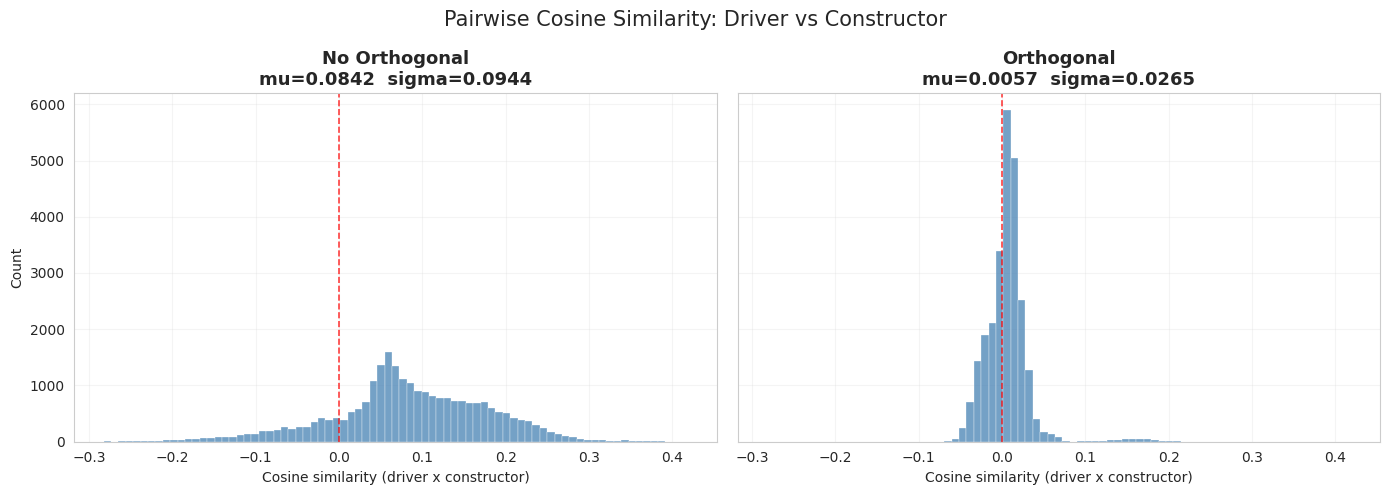

Final cosine recap


,model,mean_cos,std_cos
0,No Orthogonal,0.0842,0.0944
1,Orthogonal,0.0057,0.0265


In [55]:
# ---------------------------------------------------------------------------
# 8. Final cosine comparison (classic style)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
cosine_stats = []

# Use shared bins for a fair side-by-side comparison.
all_vals = []
for label in MODEL_LABELS:
    drv_n = analysis[label]["drv_norm"]
    cons_n = analysis[label]["cons_norm"]
    cos_mat = np.dot(drv_n, cons_n.T)
    all_vals.append(cos_mat.ravel())

bin_edges = np.linspace(min(v.min() for v in all_vals), max(v.max() for v in all_vals), 80)

for ax, label, vals in zip(axes, MODEL_LABELS, all_vals):
    ax.hist(vals, bins=bin_edges, alpha=0.75, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.axvline(x=0, color="red", linestyle="--", linewidth=1.2, alpha=0.75)
    ax.set_title(f"{label}\nmu={vals.mean():.4f}  sigma={vals.std():.4f}", fontsize=13, weight="bold")
    ax.set_xlabel("Cosine similarity (driver x constructor)")
    ax.grid(alpha=0.2)

    cosine_stats.append({
        "model": label,
        "mean_cos": float(vals.mean()),
        "std_cos": float(vals.std()),
    })

axes[0].set_ylabel("Count")
fig.suptitle("Pairwise Cosine Similarity: Driver vs Constructor", fontsize=15)
plt.tight_layout()
plt.savefig("./output/embedding_quality_final_cosine.png", dpi=220, bbox_inches="tight")
plt.show()

print("Final cosine recap")
display(pd.DataFrame(cosine_stats).round(4))

## Takeaway Template

After running all cells, summarize winners by dimension:

- **Separation**: compare `silhouette_cosine` (higher), `davies_bouldin` (lower), and `cosine_gap` (higher).
- **Retrieval**: compare `precision_at_k`, `recall_at_k`, and `top1_team_year_hit` (higher).
- **Geometry**: compare norm stability (`*_norm_std` lower), component efficiency (`pc80_components`, `pc95_components`), and angular spread centered near zero.
- **Final cosine shift**: inspect KS statistic and mean shift from the final plot.

Recommended conclusion format:

> Orthogonal model wins on [dimensions], baseline wins on [dimensions], with [brief practical implication].

In [56]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# Resolve path whether notebook runs from repo root or notebooks/
possible_paths = [
    Path("output/significance/run_results.json"),
    Path("../output/significance/run_results.json"),
]

results_path = next((p for p in possible_paths if p.exists()), None)
if results_path is None:
    raise FileNotFoundError("Could not find output/significance/run_results.json")

with results_path.open("r", encoding="utf-8") as f:
    runs = json.load(f)

records = []
for run in runs:
    level = run.get("model_level")
    val_orth = run.get("history", {}).get("val_orth", [])
    if level is None or len(val_orth) == 0:
        continue

    records.append(
        {
            "method": level,
            "run_id": run.get("run_metadata", {}).get("run_id"),
            "val_orth_last": float(val_orth[-1]),
        }
    )

df_val_orth = pd.DataFrame(records)

# 95% CI using normal approximation: mean +/- 1.96 * SEM
summary = (
    df_val_orth.groupby("method")["val_orth_last"]
    .agg(["count", "mean", "std"])
    .rename(columns={"count": "n", "std": "sd"})
)
summary["sem"] = summary["sd"] / np.sqrt(summary["n"])
summary["ci95_half_width"] = 1.96 * summary["sem"]
summary["ci95_lower"] = summary["mean"] - summary["ci95_half_width"]
summary["ci95_upper"] = summary["mean"] + summary["ci95_half_width"]

method_order = ["high", "low", "zero"]
summary = summary.reindex([m for m in method_order if m in summary.index])
summary = summary[["n", "mean", "ci95_lower", "ci95_upper", "ci95_half_width"]]

summary_rounded = summary.round(6)
print("Val orth (last epoch) summary by method with 95% CI")
display(summary_rounded)

# Optional: one small table per method
for method in summary_rounded.index:
    print(f"\nMethod: {method}")
    display(summary_rounded.loc[[method]])

Val orth (last epoch) summary by method with 95% CI


,n,mean,ci95_lower,ci95_upper,ci95_half_width
method,,,,,
high,5,0.015228,-0.000395,0.030851,0.015623
low,5,0.022306,0.007382,0.037229,0.014924
zero,5,20.850768,11.878871,29.822665,8.971897



Method: high


,n,mean,ci95_lower,ci95_upper,ci95_half_width
method,,,,,
high,5,0.015228,-0.000395,0.030851,0.015623



Method: low


,n,mean,ci95_lower,ci95_upper,ci95_half_width
method,,,,,
low,5,0.022306,0.007382,0.037229,0.014924



Method: zero


,n,mean,ci95_lower,ci95_upper,ci95_half_width
method,,,,,
zero,5,20.850768,11.878871,29.822665,8.971897
